# Patient Outcome Predictor - Simple EDA and Preprocessing

This notebook performs simple data preprocessing steps for the healthcare dataset.

## Steps:
1. Load data using pd.read_csv
2. Display data.head() and data.tail()
3. Check missing values using data.isnull().sum()
4. Delete outliers
5. Encoding categorical data
6. Feature scaling (normalization)
7. Data splitting

## About Dataset

**Source:** https://www.kaggle.com/datasets/prasad22/healthcare-dataset

### Dataset Information:

Each column provides specific information about the patient, their admission, and the healthcare services provided, making this dataset suitable for various data analysis and modeling tasks in the healthcare domain. Here's a brief explanation of each column in the dataset:

- **Name**: This column represents the name of the patient associated with the healthcare record.
- **Age**: The age of the patient at the time of admission, expressed in years.
- **Gender**: Indicates the gender of the patient, either "Male" or "Female."
- **Blood Type**: The patient's blood type, which can be one of the common blood types (e.g., "A+", "O-", etc.).
- **Medical Condition**: This column specifies the primary medical condition or diagnosis associated with the patient, such as "Diabetes," "Hypertension," "Asthma," and more.
- **Date of Admission**: The date on which the patient was admitted to the healthcare facility.
- **Doctor**: The name of the doctor responsible for the patient's care during their admission.
- **Hospital**: Identifies the healthcare facility or hospital where the patient was admitted.
- **Insurance Provider**: This column indicates the patient's insurance provider, which can be one of several options, including "Aetna," "Blue Cross," "Cigna," "UnitedHealthcare," and "Medicare."
- **Billing Amount**: The amount of money billed for the patient's healthcare services during their admission. This is expressed as a floating-point number.
- **Room Number**: The room number where the patient was accommodated during their admission.
- **Admission Type**: Specifies the type of admission, which can be "Emergency," "Elective," or "Urgent," reflecting the circumstances of the admission.
- **Discharge Date**: The date on which the patient was discharged from the healthcare facility, based on the admission date and a random number of days within a realistic range.
- **Medication**: Identifies a medication prescribed or administered to the patient during their admission. Examples include "Aspirin," "Ibuprofen," "Penicillin," "Paracetamol," and "Lipitor."
- **Test Results**: Describes the results of a medical test conducted during the patient's admission. Possible values include "Normal," "Abnormal," or "Inconclusive," indicating the outcome of the test.

## Step 1: Load Data

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold

# Load the dataset
data = pd.read_csv('/content/healthcare_dataset.csv')
print(f"Dataset shape: {data.shape}")

Dataset shape: (55500, 15)


## Step 2: Display Head and Tail

In [3]:
# Display first 5 rows
print("First 5 rows:")
data.head()

First 5 rows:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
# Display last 5 rows
print("Last 5 rows:")
data.tail()

Last 5 rows:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal
55499,jAMES GARCiA,53,Female,O+,Arthritis,2024-04-02,Dennis Warren,Henry Sons and,Aetna,4010.134172,448,Urgent,2024-04-29,Ibuprofen,Abnormal


In [5]:
# Check data types and basic information
print("Dataset Info:")
data.info()
print("\nDataset Description:")
data.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
mem

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


## Step 3: Check Missing Values

In [6]:
# Check missing values
missing_values = data.isnull().sum()
print("Missing values in each column:")
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing values in each column:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Total missing values: 0


### Handling Missing Values

Now we'll demonstrate different approaches to handle missing values:

In [7]:
# Method 1: Deletion - Remove rows with missing values (if any)
print("Method 1: Deletion")
print(f"Original dataset shape: {data.shape}")
data_clean = data.dropna()
print(f"Dataset shape after deletion: {data_clean.shape}")
print(f"Rows removed: {data.shape[0] - data_clean.shape[0]}")

# Since this dataset appears to have no missing values, let's demonstrate with artificial missing values
# Create a copy with some artificial missing values for demonstration
data_demo = data.copy()
# Artificially introduce some missing values for demonstration
np.random.seed(42)
missing_indices = np.random.choice(data_demo.index, size=20, replace=False)
data_demo.loc[missing_indices, 'Age'] = np.nan

print(f"\nDemo dataset with artificial missing values: {data_demo.isnull().sum()['Age']} missing values in Age")

Method 1: Deletion
Original dataset shape: (55500, 15)
Dataset shape after deletion: (55500, 15)
Rows removed: 0

Demo dataset with artificial missing values: 20 missing values in Age


In [8]:
# Method 2: Imputation - Replace missing values
print("Method 2: Imputation")

# Imputation with specific value (0)
data_demo_impute1 = data_demo.copy()
data_demo_impute1['Age'].fillna(0, inplace=True)
print(f"After imputing with 0: {data_demo_impute1.isnull().sum()['Age']} missing values")

# Imputation with mean
data_demo_impute2 = data_demo.copy()
age_mean = data_demo_impute2['Age'].mean()
print(f"Mean age: {age_mean:.2f}")
data_demo_impute2['Age'].fillna(age_mean, inplace=True)
print(f"After imputing with mean: {data_demo_impute2.isnull().sum()['Age']} missing values")

# Use the original data (which has no missing values) for further processing
print(f"\nUsing original data with no missing values: {data.isnull().sum().sum()} total missing")

Method 2: Imputation
After imputing with 0: 0 missing values
Mean age: 51.54
After imputing with mean: 0 missing values

Using original data with no missing values: 0 total missing


/tmp/ipython-input-2926723107.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_demo_impute1['Age'].fillna(0, inplace=True)
/tmp/ipython-input-2926723107.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

## Step 4: Handling Outliers

We'll detect and handle outliers using different methods:

Dataset shape: (55500, 16)


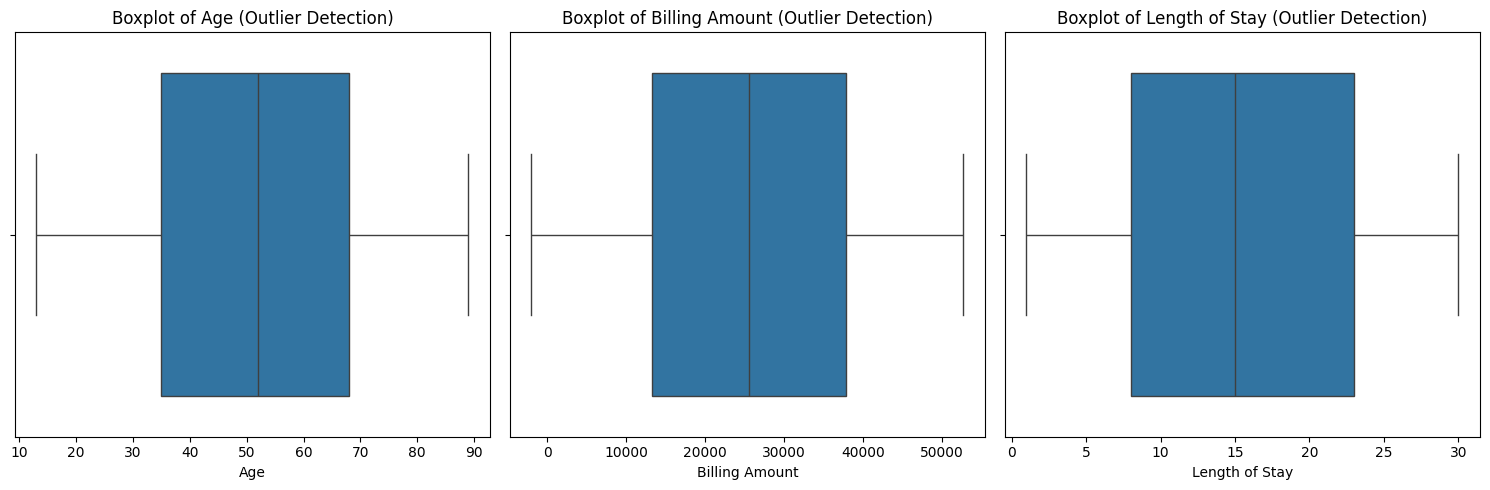


Detailed outlier analysis:


In [9]:
# Convert date columns to datetime for length of stay calculation
data['Date of Admission'] = pd.to_datetime(data['Date of Admission'])
data['Discharge Date'] = pd.to_datetime(data['Discharge Date'])
data['Length of Stay'] = (data['Discharge Date'] - data['Date of Admission']).dt.days

print(f"Dataset shape: {data.shape}")

# Identify numerical columns for outlier detection
numerical_cols = ['Age', 'Billing Amount', 'Length of Stay']

# Visualization - Boxplots for outlier detection
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    sns.boxplot(x=data[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} (Outlier Detection)")
plt.tight_layout()
plt.show()

print("\nDetailed outlier analysis:")
print("=" * 50)

Method 1: Z-score outlier detection
Age: Removed 0 outliers using Z-score method
Billing Amount: Removed 0 outliers using Z-score method
Length of Stay: Removed 0 outliers using Z-score method
Dataset shape after Z-score outlier removal: (55500, 16)


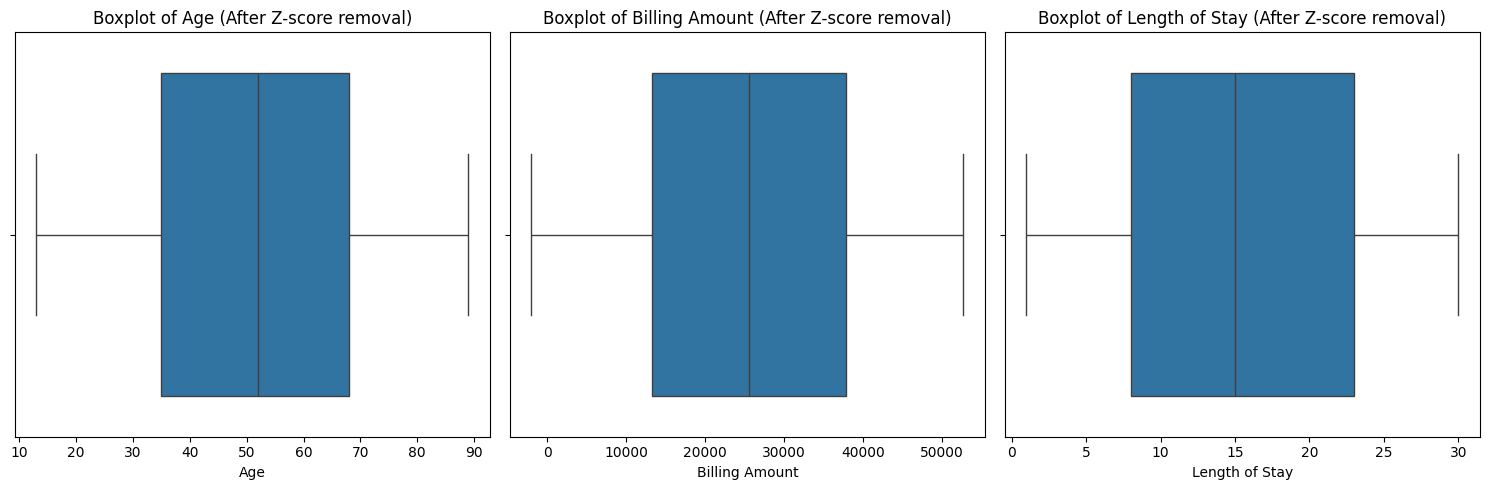

In [10]:
# Method 1: Z-score method for outlier detection and removal
print("Method 1: Z-score outlier detection")
data_zscore = data.copy()

for col in numerical_cols:
    z_scores = np.abs(stats.zscore(data_zscore[col]))
    outliers_before = len(data_zscore)
    data_zscore = data_zscore[(z_scores < 3)]
    outliers_after = len(data_zscore)
    outliers_removed = outliers_before - outliers_after

    print(f"{col}: Removed {outliers_removed} outliers using Z-score method")

print(f"Dataset shape after Z-score outlier removal: {data_zscore.shape}")

# Visualize after Z-score removal
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=data_zscore[col])
    plt.title(f"Boxplot of {col} (After Z-score removal)")
plt.tight_layout()
plt.show()

Method 2: IQR outlier detection
Age: Removed 0 outliers using IQR method
  - IQR bounds: -14.50 to 117.50
Billing Amount: Removed 0 outliers using IQR method
  - IQR bounds: -23627.70 to 74689.43
Length of Stay: Removed 0 outliers using IQR method
  - IQR bounds: -14.50 to 45.50
Dataset shape after IQR outlier removal: (55500, 16)


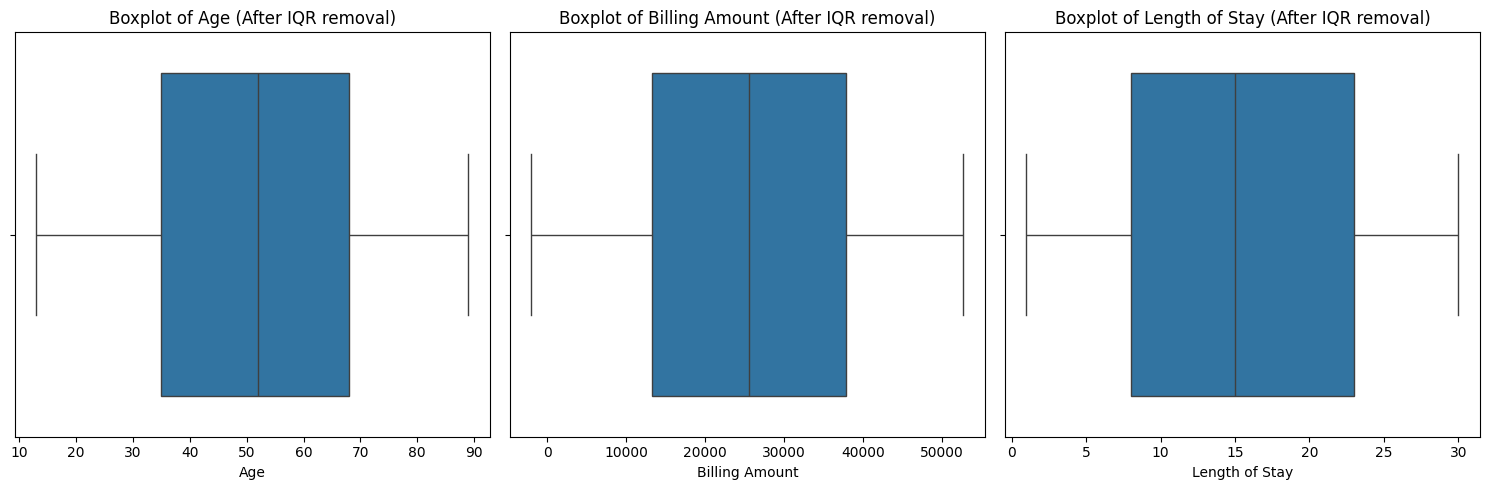


Using IQR-cleaned data for further processing: (55500, 16)


In [11]:
# Method 2: IQR method for outlier detection and removal
print("Method 2: IQR outlier detection")
data_iqr = data.copy()

for col in numerical_cols:
    Q1 = data_iqr[col].quantile(0.25)
    Q3 = data_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = len(data_iqr)
    data_iqr = data_iqr[(data_iqr[col] >= lower_bound) & (data_iqr[col] <= upper_bound)]
    outliers_after = len(data_iqr)
    outliers_removed = outliers_before - outliers_after

    print(f"{col}: Removed {outliers_removed} outliers using IQR method")
    print(f"  - IQR bounds: {lower_bound:.2f} to {upper_bound:.2f}")

print(f"Dataset shape after IQR outlier removal: {data_iqr.shape}")

# Visualize after IQR removal
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=data_iqr[col])
    plt.title(f"Boxplot of {col} (After IQR removal)")
plt.tight_layout()
plt.show()

# Use the IQR-cleaned data for further processing
print(f"\nUsing IQR-cleaned data for further processing: {data_iqr.shape}")

## Step 5: Encoding Categorical Data

In [12]:
# Use the cleaned data from IQR outlier removal
data_clean = data_iqr.copy()

# Identify categorical columns
categorical_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Admission Type',
                   'Insurance Provider', 'Medication', 'Test Results']

print("Categorical columns and their unique values:")
for col in categorical_cols:
    print(f"{col}: {data_clean[col].nunique()} unique values")
    print(f"  Values: {data_clean[col].unique()[:5]}...")  # Show first 5 values
    print()

# Method 1: Label Encoding
print("Method 1: Label Encoding")
data_label_encoded = data_clean.copy()
label_encoders = {}

for col in ['Gender', 'Admission Type', 'Test Results']:  # Binary/ordinal categories
    le = LabelEncoder()
    data_label_encoded[col + '_label_encoded'] = le.fit_transform(data_label_encoded[col])
    label_encoders[col] = le
    print(f"Label encoded {col}: {le.classes_}")

print("\nLabel encoding completed for selected columns!")

Categorical columns and their unique values:
Gender: 2 unique values
  Values: ['Male' 'Female']...

Blood Type: 8 unique values
  Values: ['B-' 'A+' 'A-' 'O+' 'AB+']...

Medical Condition: 6 unique values
  Values: ['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension']...

Admission Type: 3 unique values
  Values: ['Urgent' 'Emergency' 'Elective']...

Insurance Provider: 5 unique values
  Values: ['Blue Cross' 'Medicare' 'Aetna' 'UnitedHealthcare' 'Cigna']...

Medication: 5 unique values
  Values: ['Paracetamol' 'Ibuprofen' 'Aspirin' 'Penicillin' 'Lipitor']...

Test Results: 3 unique values
  Values: ['Normal' 'Inconclusive' 'Abnormal']...

Method 1: Label Encoding
Label encoded Gender: ['Female' 'Male']
Label encoded Admission Type: ['Elective' 'Emergency' 'Urgent']
Label encoded Test Results: ['Abnormal' 'Inconclusive' 'Normal']

Label encoding completed for selected columns!


In [13]:
# Method 2: One-Hot Encoding
print("Method 2: One-Hot Encoding")
data_onehot_encoded = data_clean.copy()

# Apply one-hot encoding to categorical columns with multiple categories
onehot_cols = ['Blood Type', 'Medical Condition', 'Insurance Provider', 'Medication']

for col in onehot_cols:
    # Use get_dummies with prefix
    dummies = pd.get_dummies(data_onehot_encoded[col], prefix=f'Is_{col.replace(" ", "_")}')
    data_onehot_encoded = pd.concat([data_onehot_encoded, dummies], axis=1)
    print(f"One-hot encoded {col}: Created {len(dummies.columns)} binary columns")

print("\nOne-hot encoding completed!")
print(f"Dataset shape after encoding: {data_onehot_encoded.shape}")

# Show some of the new columns
new_cols = [col for col in data_onehot_encoded.columns if col.startswith('Is_')]
print(f"\nSample of new one-hot encoded columns: {new_cols[:10]}")

Method 2: One-Hot Encoding
One-hot encoded Blood Type: Created 8 binary columns
One-hot encoded Medical Condition: Created 6 binary columns
One-hot encoded Insurance Provider: Created 5 binary columns
One-hot encoded Medication: Created 5 binary columns

One-hot encoding completed!
Dataset shape after encoding: (55500, 40)

Sample of new one-hot encoded columns: ['Is_Blood_Type_A+', 'Is_Blood_Type_A-', 'Is_Blood_Type_AB+', 'Is_Blood_Type_AB-', 'Is_Blood_Type_B+', 'Is_Blood_Type_B-', 'Is_Blood_Type_O+', 'Is_Blood_Type_O-', 'Is_Medical_Condition_Arthritis', 'Is_Medical_Condition_Asthma']


## Step 6: Feature Scaling

We'll demonstrate both normalization and standardization methods:

In [14]:
# Prepare data for scaling
# Use a combination of label encoding for some features and numerical features
data_for_scaling = data_clean.copy()

# Apply label encoding to all categorical columns for simplicity
for col in categorical_cols:
    le = LabelEncoder()
    data_for_scaling[col + '_encoded'] = le.fit_transform(data_for_scaling[col])

# Select numerical features for scaling
numerical_features = ['Age', 'Billing Amount', 'Room Number', 'Length of Stay']
categorical_encoded_features = [col + '_encoded' for col in categorical_cols if col != 'Test Results']

# Prepare feature matrix (exclude Test Results as it's our target)
feature_cols = numerical_features + categorical_encoded_features
X = data_for_scaling[feature_cols]

# Prepare target variable
y = data_for_scaling['Test Results_encoded']

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Features: {feature_cols}")

# Focus on numerical features for scaling demonstration
scaling_features = numerical_features
X_numeric = data_for_scaling[scaling_features]

Feature matrix shape: (55500, 10)
Target variable shape: (55500,)
Features: ['Age', 'Billing Amount', 'Room Number', 'Length of Stay', 'Gender_encoded', 'Blood Type_encoded', 'Medical Condition_encoded', 'Admission Type_encoded', 'Insurance Provider_encoded', 'Medication_encoded']


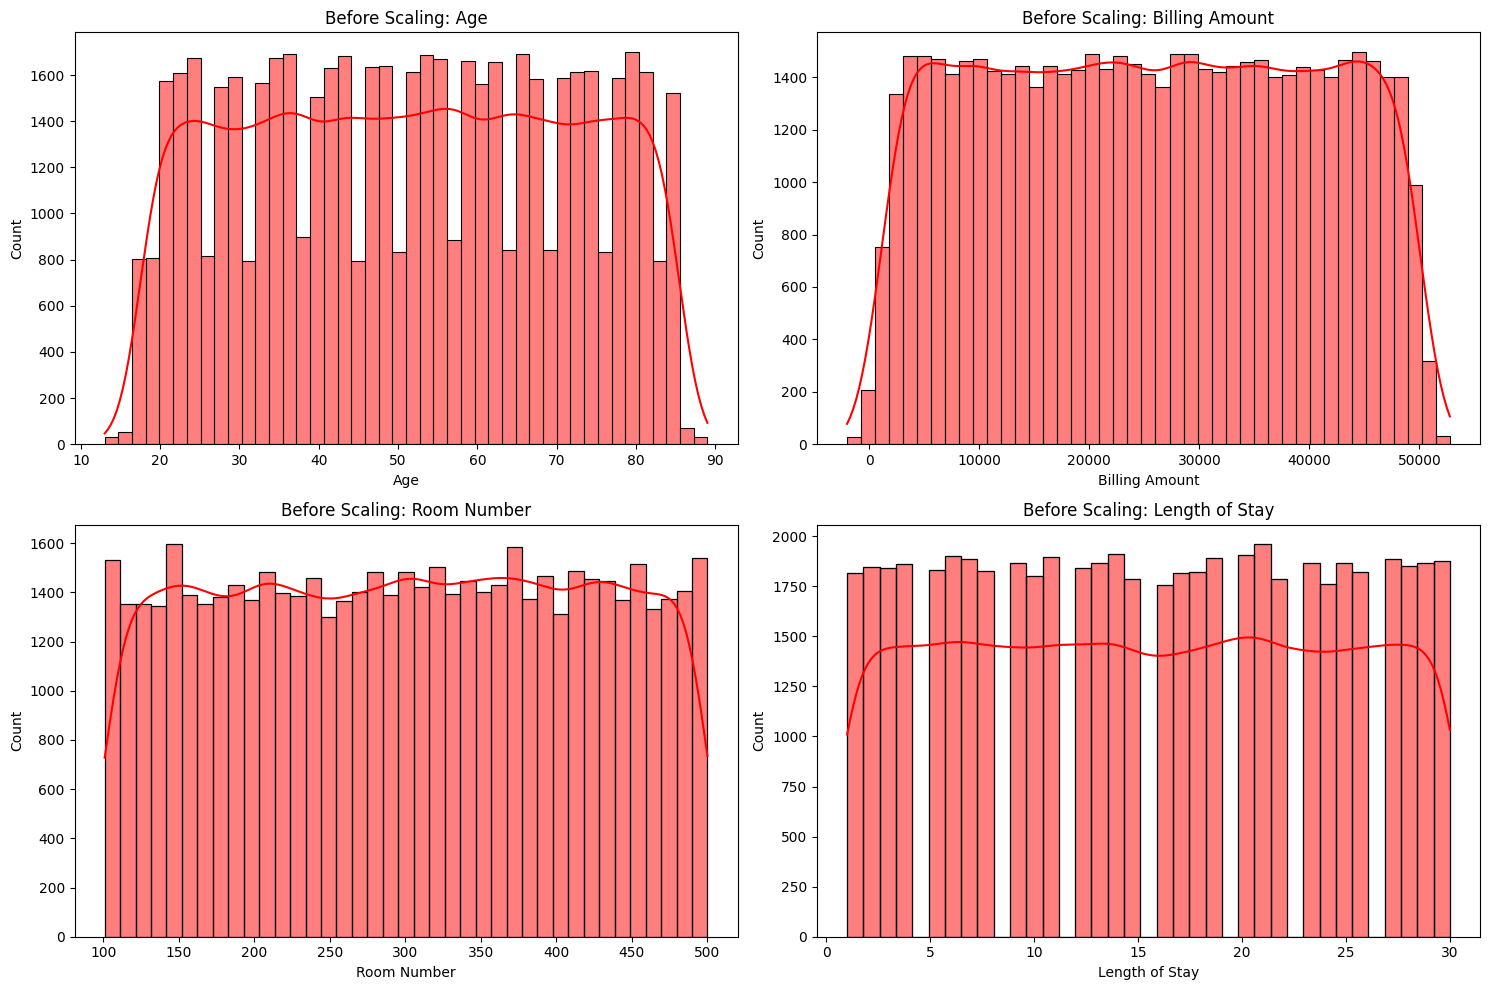

Original feature statistics:
                Age  Billing Amount   Room Number  Length of Stay
count  55500.000000    55500.000000  55500.000000    55500.000000
mean      51.539459    25539.316097    301.134829       15.509009
std       19.602454    14211.454431    115.243069        8.659600
min       13.000000    -2008.492140    101.000000        1.000000
25%       35.000000    13241.224652    202.000000        8.000000
50%       52.000000    25538.069376    302.000000       15.000000
75%       68.000000    37820.508436    401.000000       23.000000
max       89.000000    52764.276736    500.000000       30.000000


In [15]:
# Visualization before scaling
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(scaling_features):
    sns.histplot(X_numeric[col], kde=True, color='red', ax=axes[i])
    axes[i].set_title(f"Before Scaling: {col}")

plt.tight_layout()
plt.show()

print("Original feature statistics:")
print(X_numeric.describe())

Method 1: Normalization (Min-Max Scaling)
Normalized feature statistics:
                Age  Billing Amount   Room Number  Length of Stay
count  55500.000000    55500.000000  55500.000000    55500.000000
mean       0.507098        0.502947      0.501591        0.500311
std        0.257927        0.259462      0.288830        0.298607
min        0.000000        0.000000      0.000000        0.000000
25%        0.289474        0.278418      0.253133        0.241379
50%        0.513158        0.502924      0.503759        0.482759
75%        0.723684        0.727168      0.751880        0.758621
max        1.000000        1.000000      1.000000        1.000000


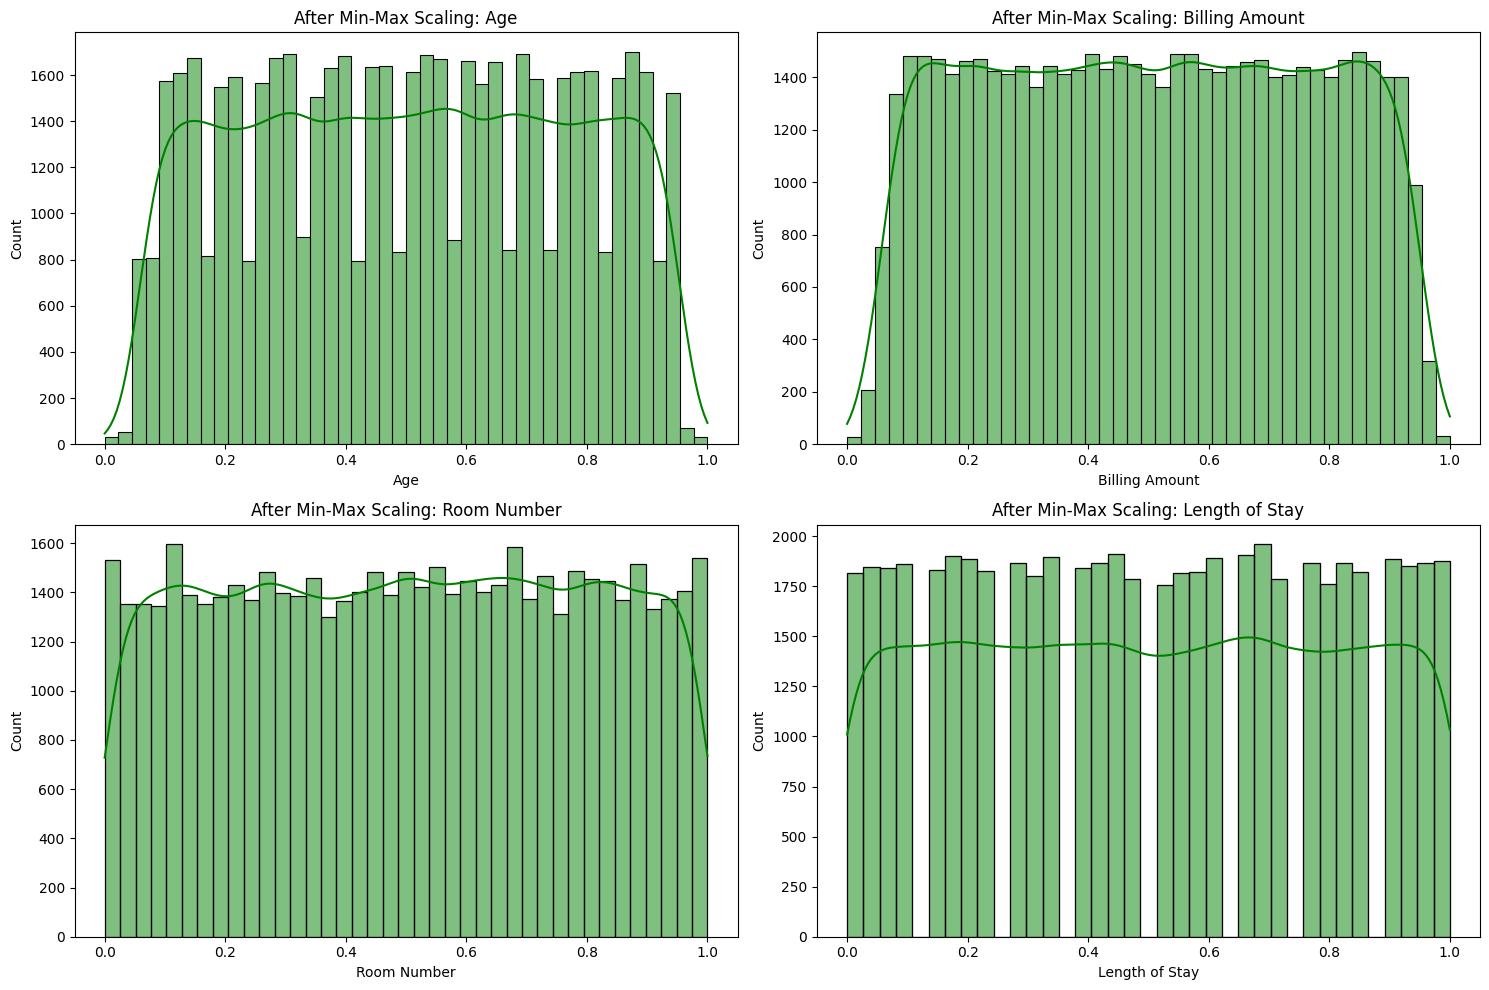

In [16]:
# Method 1: Normalization (Min-Max Scaling)
print("Method 1: Normalization (Min-Max Scaling)")
scaler_minmax = MinMaxScaler()
X_normalized = scaler_minmax.fit_transform(X_numeric)
X_normalized = pd.DataFrame(X_normalized, columns=X_numeric.columns)

print("Normalized feature statistics:")
print(X_normalized.describe())

# Visualization after normalization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(scaling_features):
    sns.histplot(X_normalized[col], kde=True, color='green', ax=axes[i])
    axes[i].set_title(f"After Min-Max Scaling: {col}")

plt.tight_layout()
plt.show()

Method 2: Standardization (Z-score normalization)
Standardized feature statistics:
                Age  Billing Amount   Room Number  Length of Stay
count  5.550000e+04    5.550000e+04  5.550000e+04    5.550000e+04
mean   7.732753e-17    5.703546e-17  2.344151e-16   -4.852175e-17
std    1.000009e+00    1.000009e+00  1.000009e+00    1.000009e+00
min   -1.966071e+00   -1.938440e+00 -1.736648e+00   -1.675498e+00
25%   -8.437519e-01   -8.653725e-01 -8.602315e-01   -8.671390e-01
50%    2.349424e-02   -8.772730e-05  7.507427e-03   -5.878027e-02
75%    8.397259e-01    8.641834e-01  8.665690e-01    8.650582e-01
max    1.911030e+00    1.915723e+00  1.725631e+00    1.673417e+00


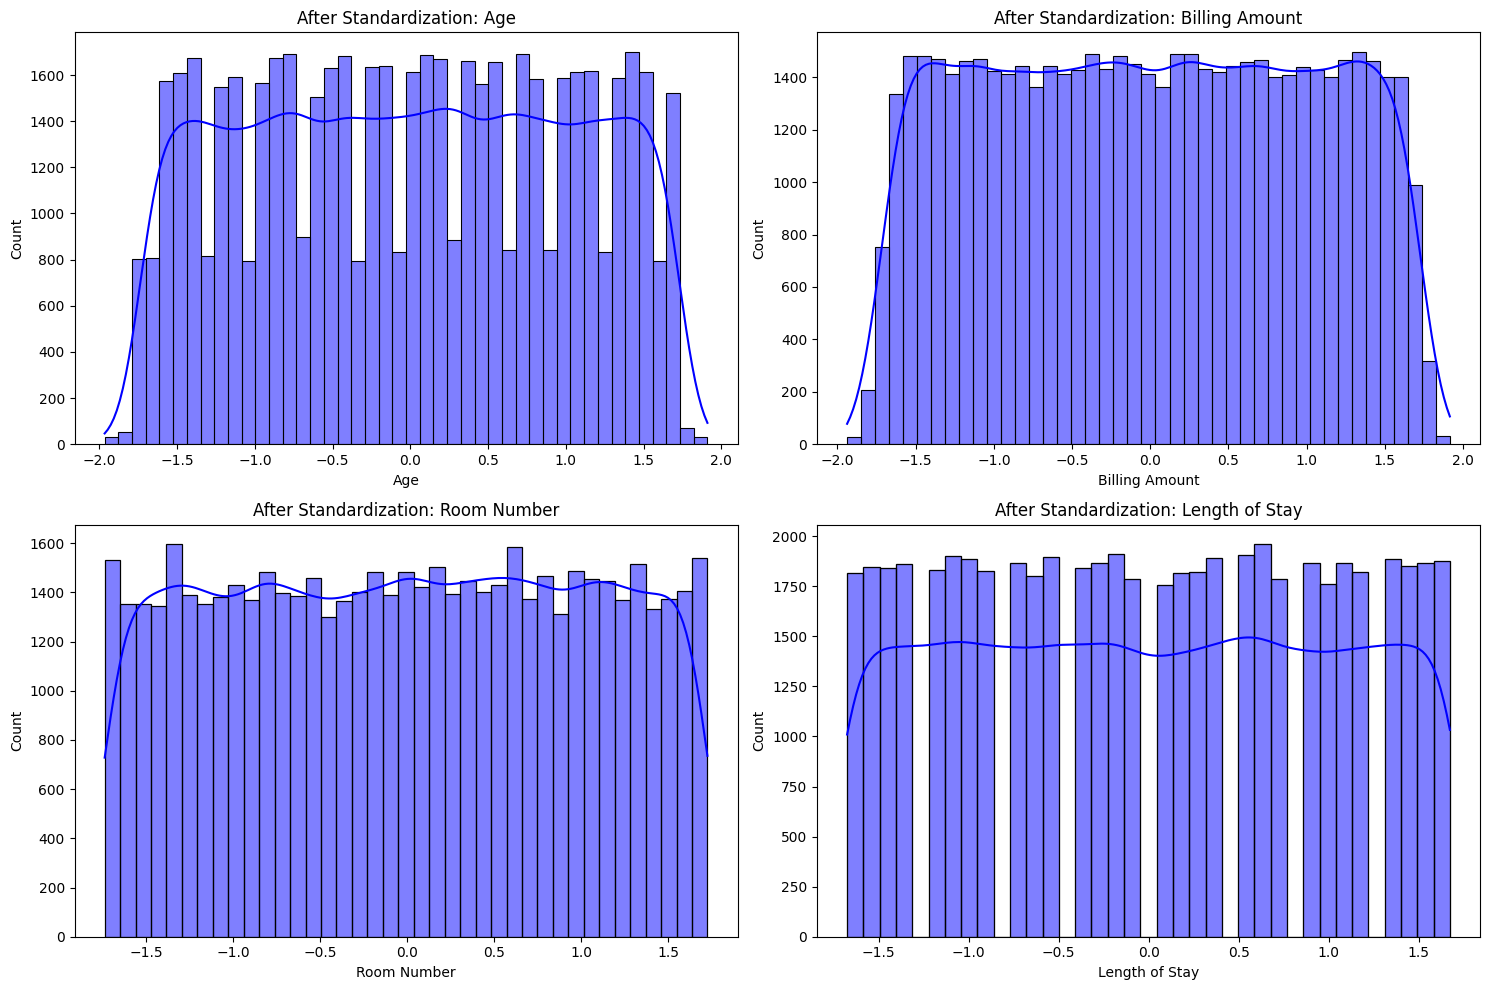


Final feature matrix shape: (55500, 10)
Final features: ['Age', 'Billing Amount', 'Room Number', 'Length of Stay', 'Gender_encoded', 'Blood Type_encoded', 'Medical Condition_encoded', 'Admission Type_encoded', 'Insurance Provider_encoded', 'Medication_encoded']


In [17]:
# Method 2: Standardization (Z-score normalization)
print("Method 2: Standardization (Z-score normalization)")
scaler_std = StandardScaler()
X_standardized = scaler_std.fit_transform(X_numeric)
X_standardized = pd.DataFrame(X_standardized, columns=X_numeric.columns)

print("Standardized feature statistics:")
print(X_standardized.describe())

# Visualization after standardization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(scaling_features):
    sns.histplot(X_standardized[col], kde=True, color='blue', ax=axes[i])
    axes[i].set_title(f"After Standardization: {col}")

plt.tight_layout()
plt.show()

# For further processing, we'll use standardized features combined with encoded categorical features
X_final = X_standardized.copy()
for col in categorical_encoded_features:
    X_final[col] = data_for_scaling[col].values

print(f"\nFinal feature matrix shape: {X_final.shape}")
print(f"Final features: {X_final.columns.tolist()}")

## Step 7: Data Splitting

We'll demonstrate both Hold-Out and K-Fold Cross-Validation methods:

In [18]:
# Method 1: Hold-Out Method
print("Method 1: Hold-Out Method")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data splitting completed!")
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")

# Display target distribution
print("\nTarget distribution in training set:")
train_dist = pd.Series(y_train).value_counts().sort_index()
print(train_dist)

print("\nTarget distribution in testing set:")
test_dist = pd.Series(y_test).value_counts().sort_index()
print(test_dist)

Method 1: Hold-Out Method
Data splitting completed!
Training set shape: X_train=(44400, 10), y_train=(44400,)
Testing set shape: X_test=(11100, 10), y_test=(11100,)

Target distribution in training set:
Test Results_encoded
0    14901
1    14685
2    14814
Name: count, dtype: int64

Target distribution in testing set:
Test Results_encoded
0    3726
1    3671
2    3703
Name: count, dtype: int64


In [19]:
# Method 2: K-Fold Cross-Validation
print("Method 2: K-Fold Cross-Validation")

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"K-Fold setup: {kf.n_splits} folds")
print("Fold information:")

fold_info = []
for fold, (train_idx, test_idx) in enumerate(kf.split(X_final)):
    X_fold_train, X_fold_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_fold_train, y_fold_test = y.iloc[train_idx], y.iloc[test_idx]

    fold_info.append({
        'fold': fold + 1,
        'train_size': len(X_fold_train),
        'test_size': len(X_fold_test),
        'train_ratio': len(X_fold_train) / len(X_final),
        'test_ratio': len(X_fold_test) / len(X_final)
    })

    print(f"Fold {fold + 1}: Train={len(X_fold_train)}, Test={len(X_fold_test)}")

# Convert to DataFrame for better visualization
fold_df = pd.DataFrame(fold_info)
print(f"\nK-Fold summary:")
print(fold_df)

Method 2: K-Fold Cross-Validation
K-Fold setup: 5 folds
Fold information:
Fold 1: Train=44400, Test=11100
Fold 2: Train=44400, Test=11100
Fold 3: Train=44400, Test=11100
Fold 4: Train=44400, Test=11100
Fold 5: Train=44400, Test=11100

K-Fold summary:
   fold  train_size  test_size  train_ratio  test_ratio
0     1       44400      11100          0.8         0.2
1     2       44400      11100          0.8         0.2
2     3       44400      11100          0.8         0.2
3     4       44400      11100          0.8         0.2
4     5       44400      11100          0.8         0.2


## Summary

In [20]:
# Final summary
print("=" * 60)
print("COMPREHENSIVE DATA PREPROCESSING COMPLETED")
print("=" * 60)

print(f"✓ Original data loaded: {data.shape[0]} records, {data.shape[1]} columns")
print(f"✓ Dataset information: Healthcare dataset from Kaggle")
print(f"✓ Missing values handled: {data.isnull().sum().sum()} total missing (demonstrated methods)")
print(f"✓ Outliers detected and removed using IQR method: {data.shape[0] - data_iqr.shape[0]} outliers removed")
print(f"✓ Final cleaned dataset: {data_iqr.shape[0]} records")

print(f"\nEncoding Methods Applied:")
print(f"✓ Label Encoding: Applied to binary/ordinal categorical variables")
print(f"✓ One-Hot Encoding: Applied to nominal categorical variables")

print(f"\nScaling Methods Demonstrated:")
print(f"✓ Min-Max Normalization: Scaled features to [0,1] range")
print(f"✓ Standardization: Scaled features to mean=0, std=1")

print(f"\nData Splitting Methods:")
print(f"✓ Hold-Out Method: {X_train.shape[0]} training, {X_test.shape[0]} testing (80/20 split)")
print(f"✓ K-Fold Cross-Validation: 5-fold setup demonstrated")

print(f"\nFinal preprocessed data ready for ML:")
print(f"✓ Feature matrix: {X_final.shape[1]} features")
print(f"✓ Target variable: {len(y.unique())} classes")
print(f"✓ Ready for model training and evaluation!")

print("\n" + "=" * 60)
print("All preprocessing steps completed successfully!")
print("Data is now ready for machine learning model development.")
print("=" * 60)

COMPREHENSIVE DATA PREPROCESSING COMPLETED
✓ Original data loaded: 55500 records, 16 columns
✓ Dataset information: Healthcare dataset from Kaggle
✓ Missing values handled: 0 total missing (demonstrated methods)
✓ Outliers detected and removed using IQR method: 0 outliers removed
✓ Final cleaned dataset: 55500 records

Encoding Methods Applied:
✓ Label Encoding: Applied to binary/ordinal categorical variables
✓ One-Hot Encoding: Applied to nominal categorical variables

Scaling Methods Demonstrated:
✓ Min-Max Normalization: Scaled features to [0,1] range
✓ Standardization: Scaled features to mean=0, std=1

Data Splitting Methods:
✓ Hold-Out Method: 44400 training, 11100 testing (80/20 split)
✓ K-Fold Cross-Validation: 5-fold setup demonstrated

Final preprocessed data ready for ML:
✓ Feature matrix: 10 features
✓ Target variable: 3 classes
✓ Ready for model training and evaluation!

All preprocessing steps completed successfully!
Data is now ready for machine learning model development